# Campaign Finance Regulatory Score (CFRS) — Latin America & Caribbean
### Does having stronger campaign finance laws correlate with lower corruption?
**Data sources:** International IDEA Political Finance Database · Transparency International CPI 2025  
**Author:** Angello Leon

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

print("Libraries loaded ✓")

Libraries loaded ✓


## 1. The Data
We score 32 countries across 12 campaign finance variables drawn from the IDEA Political Finance Database, grouped into 4 pillars: Prohibitions, Spending Limits, Transparency, and Enforcement.

In [2]:
cfrs = pd.read_csv('../data/processed/cfrs_scores.csv')
cfrs = cfrs[['Country', 'ISO3', 'CFRS_scaled']].copy()
print(f"Countries scored: {len(cfrs)}")
cfrs.sort_values('CFRS_scaled', ascending=False).head(10)

Countries scored: 32


,Country,ISO3,CFRS_scaled
6,Brazil,BRA,95.83
11,Dominican Republic,DOM,95.83
20,Mexico,MEX,95.83
8,Colombia,COL,87.50
18,Honduras,HND,87.50
7,Chile,CHL,87.50
12,Ecuador,ECU,83.33
15,Guatemala,GTM,83.33
1,Argentina,ARG,83.33
22,Panama,PAN,83.33


In [3]:
cpi = pd.read_csv('../data/raw/CPI2025_Results.csv')
cpi = cpi[cpi['Region'] == 'AME'][['Country / Territory', 'ISO3', 'CPI 2025 score']].copy()
cpi.columns = ['Country_CPI', 'ISO3', 'CPI_2025']
cpi['CPI_2025'] = pd.to_numeric(cpi['CPI_2025'], errors='coerce')
print(f"CPI countries loaded: {len(cpi)}")
cpi.sort_values('CPI_2025', ascending=False).head(10)

CPI countries loaded: 33


,Country_CPI,ISO3,CPI_2025
15,Canada,CAN,75
16,Uruguay,URY,73
23,Barbados,BRB,68
28,Bahamas,BHS,64
29,United States of America,USA,64
31,Chile,CHL,63
33,Saint Vincent and the Grenadines,VCT,63
36,Dominica,DMA,60
39,Saint Lucia,LCA,59
45,Costa Rica,CRI,56


## 2. Merging the Datasets
We join the CFRS scores with CPI scores using the ISO3 country code as the common key.

In [4]:
merged = cfrs.merge(cpi[['ISO3', 'CPI_2025']], on='ISO3', how='inner')
merged = merged.dropna(subset=['CFRS_scaled', 'CPI_2025'])

# Clean display table
display = merged[['Country', 'CFRS_scaled', 'CPI_2025']].sort_values('CFRS_scaled', ascending=False).copy()
display.columns = ['Country', 'CFRS Score (0-100)', 'CPI 2025 (0-100)']
print(f"Countries in final analysis: {len(merged)}")
display

Countries in final analysis: 30


,Country,CFRS Score (0-100),CPI 2025 (0-100)
5,Brazil,95.83,35
10,Dominican Republic,95.83,37
19,Mexico,95.83,27
6,Chile,87.50,63
17,Honduras,87.50,22
7,Colombia,87.50,37
14,Guatemala,83.33,26
21,Panama,83.33,33
11,Ecuador,83.33,33
0,Argentina,83.33,36


## 3. Correlation Analysis
We use the Spearman rank correlation — appropriate here because our data is ordinal 
and we don't assume a perfectly linear relationship.

In [5]:
rho, pval = stats.spearmanr(merged['CFRS_scaled'], merged['CPI_2025'])

print(f"Spearman ρ  =  {rho:.3f}")
print(f"p-value     =  {pval:.4f}")
print()
if pval < 0.05:
    print("✓ Statistically significant at the 95% confidence level")
else:
    print("✗ Not statistically significant (p > 0.05)")

Spearman ρ  =  -0.428
p-value     =  0.0182

✓ Statistically significant at the 95% confidence level


## 3b. Robustness Checks

The headline result depends on two analytical choices: how the 12 variables are
weighted, and how "No data" responses are treated. To test whether the finding
survives reasonable alternatives, the correlation is recomputed three ways:

1. **Baseline** — all 12 variables weighted equally; "No data" scored as 0 (absence of a rule).
2. **Pillar-weighted** — each of the 4 pillars contributes 25% regardless of how many
   variables it contains (corrects the implicit double-weighting of Prohibitions and Transparency).
3. **No-data dropped** — "No data" responses excluded from the average rather than scored 0
   (tests whether treating missing data as absence drives the result).

In [6]:
# Re-score from raw IDEA data, preserving NaN for "No data"
# (the processed cfrs_scores.csv already zeroes No-data, so we re-derive here)
# NOTE: scoring logic mirrors build_cfrs.py — kept inline for a self-contained narrative.

raw = pd.read_csv('../data/raw/export_table_raw.csv', encoding='utf-8',
                  on_bad_lines='skip', header=None)
h = raw.iloc[1].tolist()
d = raw.iloc[2:].copy(); d.columns = h; d = d.reset_index(drop=True)

cmap = {h[0]:"Country", h[2]:"ISO3",
        h[3]:"A1", h[9]:"A2", h[5]:"A3", h[29]:"A4",
        h[43]:"B1", h[41]:"B2",
        h[54]:"C1", h[56]:"C2", h[50]:"C3", h[49]:"C4",
        h[58]:"D1", h[60]:"D2"}
d = d.rename(columns=cmap)[list(cmap.values())].copy()

def s_yesno(v):
    v = str(v).strip()
    if v == "Yes": return 1.0
    if v in ("Yes, above certain threshold", "Sometimes"): return 0.5
    if v in ("No", "Not applicable", "nan"): return 0.0
    if v == "No data": return np.nan
    return 0.5 if v.lower().startswith("yes") else 0.0

def s_oversight(v):
    v = str(v).strip()
    if v == "No data": return np.nan
    if v == "No institution specified": return 0.0
    if "Special agency for political finance" in v: return 1.0
    if any(x in v for x in ("EMB", "Court", "Auditing agency", "Ministry")): return 0.5
    return 0.0

def s_sanctions(v):
    v = str(v).strip()
    if v in ("Not applicable", "nan", ""): return 0.0
    if any(x in v for x in ("Prison", "Deregistration", "Loss of elected office")): return 1.0
    if "Fines" in v or "Loss of public funding" in v: return 0.5
    return 0.0

var_cols = ["A1","A2","A3","A4","B1","B2","C1","C2","C3","C4","D1","D2"]
for c in var_cols:
    fn = s_oversight if c == "D1" else s_sanctions if c == "D2" else s_yesno
    d[f"s_{c}"] = d[c].apply(fn)

S = [f"s_{c}" for c in var_cols]
pillars = {"A": ["s_A1","s_A2","s_A3","s_A4"], "B": ["s_B1","s_B2"],
           "C": ["s_C1","s_C2","s_C3","s_C4"], "D": ["s_D1","s_D2"]}

d["CFRS_baseline"] = d[S].fillna(0).mean(axis=1) * 100
d["CFRS_pillar"]   = pd.DataFrame({p: d[c].fillna(0).mean(axis=1)
                                   for p, c in pillars.items()}).mean(axis=1) * 100
d["CFRS_nodrop"]   = d[S].mean(axis=1, skipna=True) * 100

rob = d.merge(cpi[["ISO3","CPI_2025"]], on="ISO3", how="inner").dropna(subset=["CPI_2025"])

print(f"{'Method':<34}{'rho':>8}{'p-value':>10}{'n':>5}")
print("-" * 57)
for label, col in [("Baseline (equal-variable)", "CFRS_baseline"),
                   ("Pillar-weighted (25% each)", "CFRS_pillar"),
                   ("No-data dropped", "CFRS_nodrop")]:
    sub = rob.dropna(subset=[col])
    r, p = stats.spearmanr(sub[col], sub["CPI_2025"])
    flag = "significant" if p < 0.05 else "n.s."
    print(f"{label:<34}{r:>8.3f}{p:>10.4f}{len(sub):>5}  ({flag})")

Method                                 rho   p-value    n
---------------------------------------------------------
Baseline (equal-variable)           -0.428    0.0182   30  (significant)
Pillar-weighted (25% each)          -0.428    0.0184   30  (significant)
No-data dropped                     -0.434    0.0166   30  (significant)


## 4. Visualization

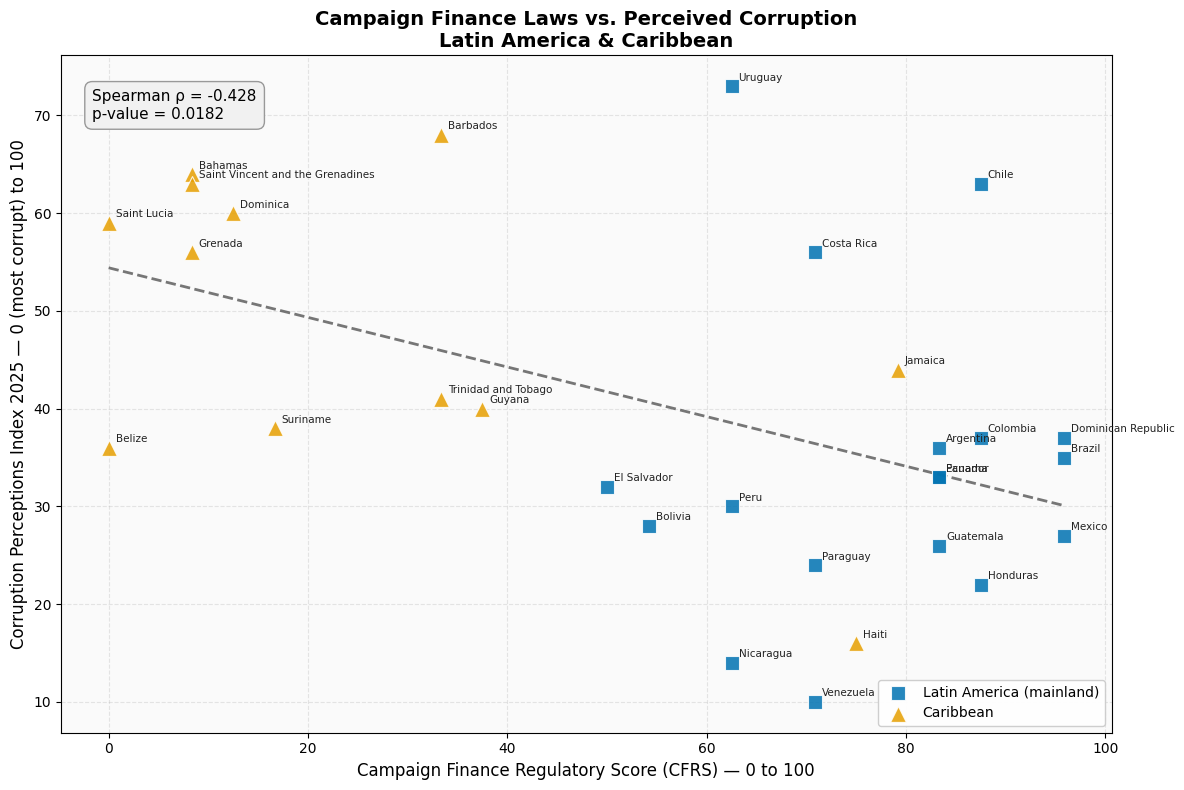

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

caribbean = ['Antigua and Barbuda','Bahamas','Barbados','Belize','Cuba','Dominica',
             'Grenada','Guyana','Haiti','Jamaica','Saint Kitts and Nevis','Saint Lucia',
             'Saint Vincent and the Grenadines','Suriname','Trinidad and Tobago']

merged['is_caribbean'] = merged['Country'].isin(caribbean)
mainland = merged[~merged['is_caribbean']]
carib    = merged[merged['is_caribbean']]

# Colorblind-safe palette (Okabe-Ito); shape distinguishes groups even in grayscale.
# Neither colour implies good/bad, unlike red.
BLUE   = '#0072B2'   # Latin America (mainland) — squares
ORANGE = '#E69F00'   # Caribbean — triangles

ax.scatter(mainland['CFRS_scaled'], mainland['CPI_2025'],
           marker='s', s=110, c=BLUE, alpha=0.85, edgecolors='white', linewidth=0.8,
           zorder=3, label='Latin America (mainland)')
ax.scatter(carib['CFRS_scaled'], carib['CPI_2025'],
           marker='^', s=130, c=ORANGE, alpha=0.85, edgecolors='white', linewidth=0.8,
           zorder=3, label='Caribbean')

for _, row in merged.iterrows():
    ax.annotate(row['Country'],
                xy=(row['CFRS_scaled'], row['CPI_2025']),
                xytext=(5, 4), textcoords='offset points',
                fontsize=7.5, color='#222222')

m, b = np.polyfit(merged['CFRS_scaled'], merged['CPI_2025'], 1)
x_line = np.linspace(merged['CFRS_scaled'].min(), merged['CFRS_scaled'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#555555', linewidth=2, linestyle='--', alpha=0.8, zorder=2)

ax.text(0.03, 0.95, f"Spearman ρ = {rho:.3f}\np-value = {pval:.4f}",
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F1F1F1', edgecolor='#999999'))

ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.set_xlabel('Campaign Finance Regulatory Score (CFRS) — 0 to 100', fontsize=12)
ax.set_ylabel('Corruption Perceptions Index 2025 — 0 (most corrupt) to 100', fontsize=12)
ax.set_title('Campaign Finance Laws vs. Perceived Corruption\nLatin America & Caribbean',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#FAFAFA')
plt.tight_layout()

# Save the figure so outputs/ stays in sync with the notebook
plt.savefig('../outputs/cfrs_vs_cpi.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Key Findings

- **Spearman ρ = -0.428** indicates a moderate *negative* correlation between CFRS and CPI scores
- Countries with *more* campaign finance laws tend to score *lower* on the corruption perception index
- This reflects **reactive legislation** — countries with higher corruption are more likely to have passed reform laws in response to public pressure
- Caribbean small island states cluster top-left — low regulatory scores but relatively higher CPI, likely due to simpler political economies
- **Chile and Uruguay** stand out as strongest performers on both dimensions — strong laws *and* lower perceived corruption

## 6. Limitations & Next Steps

- CPI measures *perceptions* of corruption, not actual corruption
- IDEA data reflects laws on paper, not enforcement quality
- Future work: add World Bank Control of Corruption index, GDP per capita as a control variable, and a press freedom score
- Sample size (n=30) limits statistical power — findings are suggestive, not definitive